In [3]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
from pythainlp import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import os

train_df = pd.read_csv('train_data.csv')

# ตัดคำ
train_df['Tokens'] = train_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))

# สร้าง Tokenizer
vocab_size = 5000 
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(train_df['Tokens'])

# แปลงคำศัพท์เป็นตัวเลข และทำ Padding
max_len = 80  # 
train_sequences = tokenizer.texts_to_sequences(train_df['Tokens'])
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
y_train = train_df['Label'].values
 
print(f"Train set shape: {X_train.shape}")

data_path = '../data/'

np.save(os.path.join(data_path, 'X_train.npy'), X_train)
np.save(os.path.join(data_path, 'y_train.npy'), y_train)

print("บันทึก X_train และ y_train เรียบร้อยแล้ว")

Train set shape: (541, 80)
บันทึก X_train และ y_train เรียบร้อยแล้ว


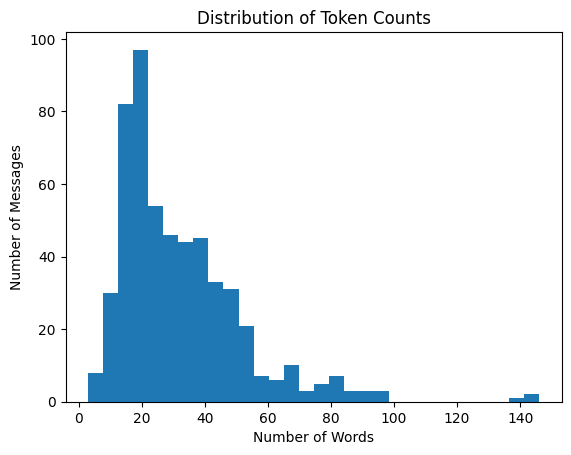

In [4]:
import matplotlib.pyplot as plt

token_counts = train_df['Tokens'].apply(len)
plt.hist(token_counts, bins=30)
plt.title('Distribution of Token Counts')
plt.xlabel('Number of Words')
plt.ylabel('Number of Messages')
plt.show()

In [ ]:
print(train_df['Tokens'].apply(len).quantile(0.9))

69.0


In [ ]:
print(train_df[['Text', 'Tokens']].head())
print(f"ตัวอย่างการตัดคำแถวที่ 1: {train_df['Tokens'].iloc[0]}")

                                                Text  \
0  ิยินดีด้วย! คุณได้รับเงินคืนจากกองทุน 1,000,00...   
1  สมัคຣสมๅชิกรับฟรีสปิuທັuที 1 เกມส์\r\nคลิ๊ກ ht...   
2  ลูกค้าทรูไอดี รับชมซีรีส์จีน 'เล่ห์รักวังคุนหน...   
3  ประกันสุขภาพเหมาจ่าย AIA HealthSaver คุ้มครองส...   
4  ทรูพอยท์แลกลุ้นรวย แจกใหญ่ทอง 5 บาท เริ่ม 9 ทร...   

                                              Tokens  
0  [ิ, ยินดี, ด้วย, !,  , คุณ, ได้, รับเงิน, คืน,...  
1  [ส, มัค, ຣ, สม, ๅ, ชิ, กรับ, ฟรี, สปิ, u, ທັu,...  
2  [ลูกค้า, ทรู, ไอ, ดี,  , รับ, ชม, ซีรีส์, จีน,...  
3  [ประกัน, สุขภาพ, เหมาจ่าย,  , AIA,  , HealthSa...  
4  [ทรู, พอยท์, แลก, ลุ้น, รวย,  , แจก, ใหญ่, ทอง...  
ตัวอย่างการตัดคำแถวที่ 1: ['ิ', 'ยินดี', 'ด้วย', '!', ' ', 'คุณ', 'ได้', 'รับเงิน', 'คืน', 'จาก', 'กองทุน', ' ', '1,000,000', ' ', 'บาท']


BASELINE--run

In [ ]:
import pandas as pd
import re
from pythainlp import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

train_df = pd.read_csv('train_data.csv')

# ทำความสะอาดและตัดคำ
def custom_thai_tokenizer(text):
    text = str(text)
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
    return word_tokenize(text, engine='newmm')

print("กำลังแปลงข้อความเป็น TF-IDF Matrix")

# สร้าง TF-IDF Vectorizer และเรียนรู้คำจากชุด Train
tfidf = TfidfVectorizer(tokenizer=custom_thai_tokenizer, token_pattern=None, max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df['Text'])
y_train = train_df['Label'].values

print(f"ตาราง TF-IDF: {X_train_tfidf.shape}")

# สร้างและเทรนโมเดล Logistic Regression
print("\n เริ่มเทรนโมเดล Logistic Regression")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# ให้โมเดลทำนายข้อมูลชุดเดิมที่เพิ่งเรียนไป
y_train_pred = model.predict(X_train_tfidf)

print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")
print(classification_report(y_train, y_train_pred, target_names=['Normal (0)', 'Scam (1)']))

กำลังแปลงข้อความเป็น TF-IDF Matrix
ตาราง TF-IDF: (541, 2790)

 เริ่มเทรนโมเดล Logistic Regression
Accuracy: 0.95
              precision    recall  f1-score   support

  Normal (0)       0.95      0.96      0.95       273
    Scam (1)       0.96      0.95      0.95       268

    accuracy                           0.95       541
   macro avg       0.95      0.95      0.95       541
weighted avg       0.95      0.95      0.95       541



In [9]:
val_df = pd.read_csv('val_data.csv')

val_df['Tokens'] = val_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))
val_sequences = tokenizer.texts_to_sequences(val_df['Tokens'])

X_val = pad_sequences(val_sequences, maxlen=max_len, padding='post')
y_val = val_df['Label'].values

print(f"Validation set shape: {X_val.shape}")

Validation set shape: (116, 50)


In [24]:
print(val_df['Tokens'].apply(len).quantile(0.99))

86.69999999999999


In [ ]:
test_df = pd.read_csv('test.csv')
test_df['Tokens'] = test_df['Text'].apply(lambda x: word_tokenize(str(x), engine='newmm'))

test_sequences = tokenizer.texts_to_sequences(test_df['Tokens'])
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')
y_test = test_df['Label'].values

print(f"Test set shape: {X_test.shape}")